# Build a deep learning model that can remove noise from images using an autoencoder on MNIST

In [4]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Transform
transform = transforms.ToTensor()

# Data
train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

# Dataloaders
valid_size = 0.2
batch_size = 20
num_workers = 0

train_length = len(train_data)
indices = list(range(train_length))
np.random.shuffle(indices)

split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

print(len(train_loader), len(valid_loader), len(test_loader))

cpu


100%|██████████| 9.91M/9.91M [00:02<00:00, 3.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 140kB/s]
100%|██████████| 1.65M/1.65M [00:45<00:00, 36.6kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.53MB/s]

2400 600 500


torch.Size([20, 1, 28, 28]) torch.Size([20])


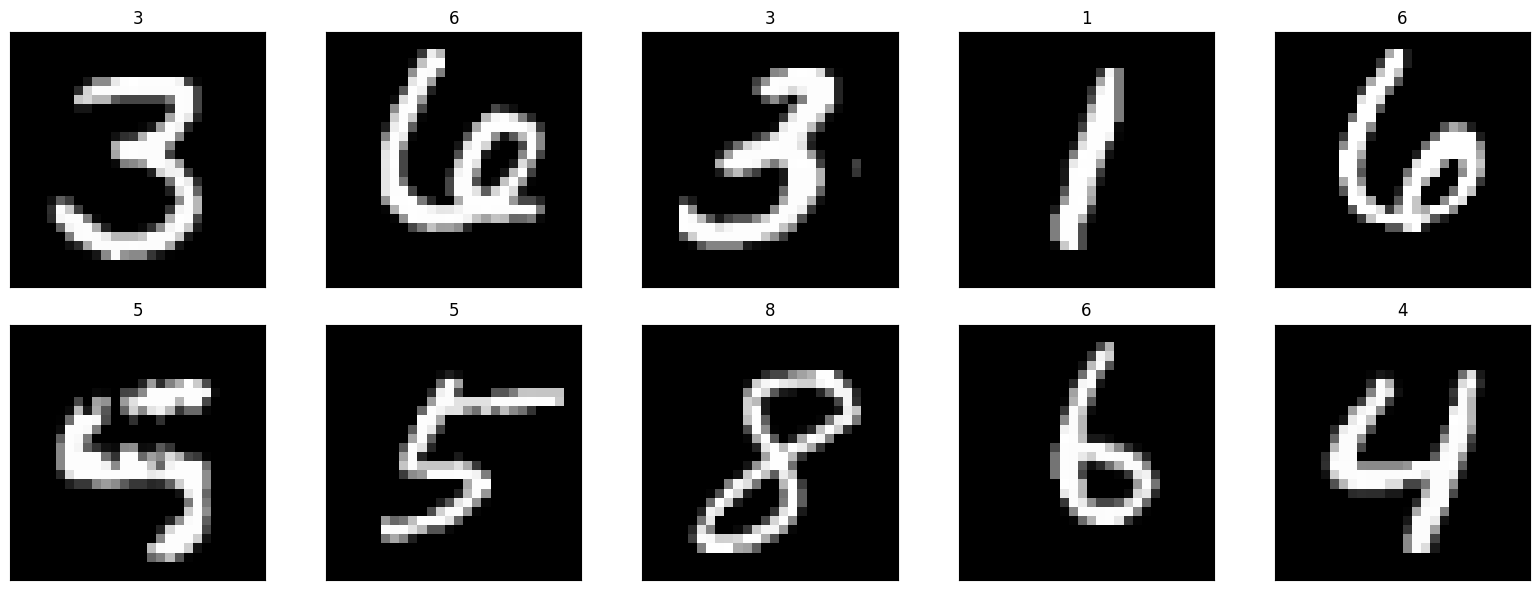

In [5]:
# Check one batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(images.shape, labels.shape)

fig = plt.figure(figsize=(16, 6))
for i in range(10):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[i]), cmap="gray")
    ax.set_title(str(labels[i].item()))
plt.tight_layout()

In [6]:
# Models
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim):
        super().__init__()
        self.encoder = nn.Linear(784, en_dim)
        self.decoder = nn.Linear(en_dim, 784)

    def forward(self, x):
        x = F.relu(self.encoder(x))
        x = torch.sigmoid(self.decoder(x))
        return x


class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.de_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.relu(self.de_conv1(x))
        x = torch.sigmoid(self.de_conv2(x))
        return x


class UpsampConvAutoMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.de_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.sigmoid(self.de_conv2(x))
        return x


model_1 = F_Auto_MNIST(32).to(device)
model_2 = Tran_conv_Auto_MNIST().to(device)
model_3 = UpsampConvAutoMNIST().to(device)

criterion = nn.MSELoss()

print(model_1)
print(model_2)
print(model_3)

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
)
Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
)
UpsampConvAutoMNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [7]:
# Training
def trainNet(model, lr, state="fully", epochs=20, save_name=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_keeper = {"train": [], "valid": []}
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        model.train()
        for images, _ in train_loader:
            images = images.to(device)
            inputs = images.view(images.size(0), -1) if state == "fully" else images

            optimizer.zero_grad()
            output = model(inputs)
            target = images.view(images.size(0), -1) if state == "fully" else images
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        with torch.no_grad():
            for images, _ in valid_loader:
                images = images.to(device)
                inputs = images.view(images.size(0), -1) if state == "fully" else images
                output = model(inputs)
                target = images.view(images.size(0), -1) if state == "fully" else images
                loss = criterion(output, target)
                valid_loss += loss.item()

        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)

        loss_keeper["train"].append(train_loss)
        loss_keeper["valid"].append(valid_loss)

        print(f"Epoch {epoch + 1}: train={train_loss:.6f}, valid={valid_loss:.6f}")

        if valid_loss <= valid_loss_min and save_name is not None:
            print(f"Validation loss decreased: {valid_loss_min:.6f} -> {valid_loss:.6f}")
            torch.save(model.state_dict(), save_name)
            valid_loss_min = valid_loss

    return loss_keeper

In [8]:
# Train models
m1_loss = trainNet(model_1, 0.01, state="fully", save_name="F_Auto_MNIST_model.pth")
m2_loss = trainNet(model_2, 0.01, state="conv", save_name="Tran_conv_Auto_MNIST_model.pth")
m3_loss = trainNet(model_3, 0.01, state="conv", save_name="upsamp_conv_Auto_MNIST_model.pth")

Epoch 1: train=0.027789, valid=0.024450
Validation loss decreased: inf -> 0.024450
Epoch 2: train=0.024141, valid=0.023963
Validation loss decreased: 0.024450 -> 0.023963
Epoch 3: train=0.023845, valid=0.023969
Epoch 4: train=0.023679, valid=0.023321
Validation loss decreased: 0.023963 -> 0.023321
Epoch 5: train=0.023507, valid=0.023766
Epoch 6: train=0.023433, valid=0.023341
Epoch 7: train=0.023395, valid=0.023318
Validation loss decreased: 0.023321 -> 0.023318
Epoch 8: train=0.023373, valid=0.023843
Epoch 9: train=0.023332, valid=0.023327
Epoch 10: train=0.023328, valid=0.023280
Validation loss decreased: 0.023318 -> 0.023280
Epoch 11: train=0.023325, valid=0.023379
Epoch 12: train=0.023308, valid=0.023324
Epoch 13: train=0.023318, valid=0.023082
Validation loss decreased: 0.023280 -> 0.023082
Epoch 14: train=0.023308, valid=0.023321
Epoch 15: train=0.023265, valid=0.023257
Epoch 16: train=0.023296, valid=0.023171
Epoch 17: train=0.023288, valid=0.023648
Epoch 18: train=0.023277, val

In [9]:
# Load best weights
model_1.load_state_dict(torch.load("F_Auto_MNIST_model.pth", map_location=device))
model_2.load_state_dict(torch.load("Tran_conv_Auto_MNIST_model.pth", map_location=device))
model_3.load_state_dict(torch.load("upsamp_conv_Auto_MNIST_model.pth", map_location=device))

<All keys matched successfully>

In [10]:
# Testing
def test(model, state="fully"):
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    images = images.to(device)
    inputs = images.view(images.size(0), -1) if state == "fully" else images

    with torch.no_grad():
        output = model(inputs)

    images = images.cpu().numpy()
    output = output.cpu().numpy()

    if state == "fully":
        output = output.reshape(batch_size, 1, 28, 28)

    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(20, 4), sharex=True, sharey=True)
    for row_images, row_axes in zip([images, output], axes):
        for img, ax in zip(row_images[:10], row_axes):
            ax.imshow(np.squeeze(img), cmap="gray")
            ax.axis("off")
    plt.tight_layout()

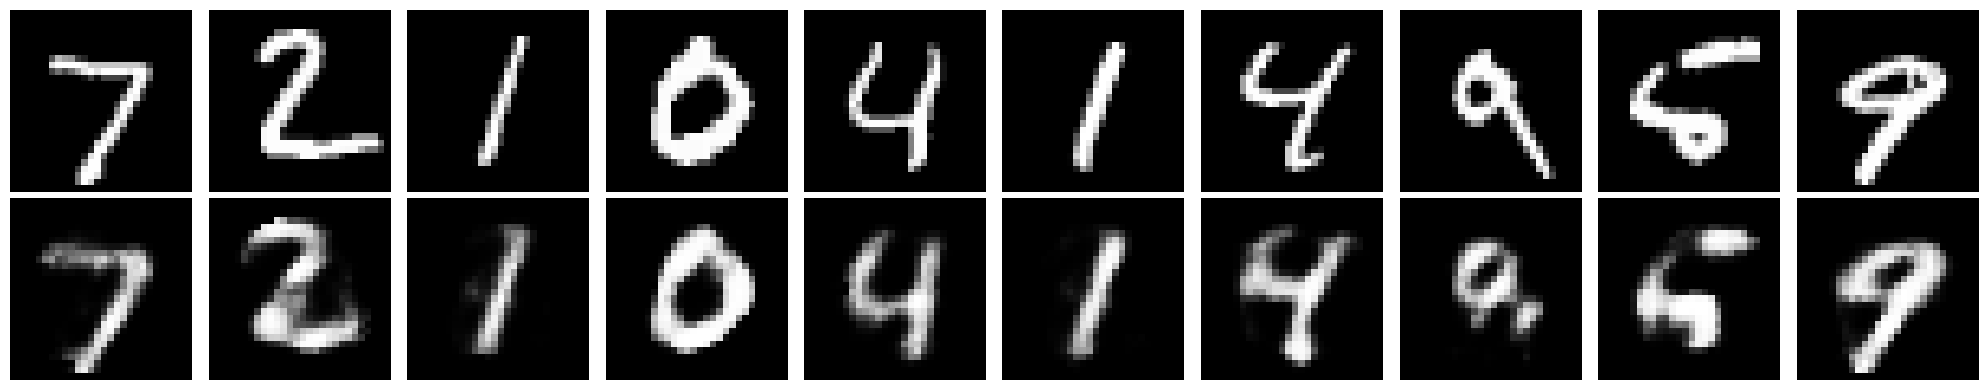

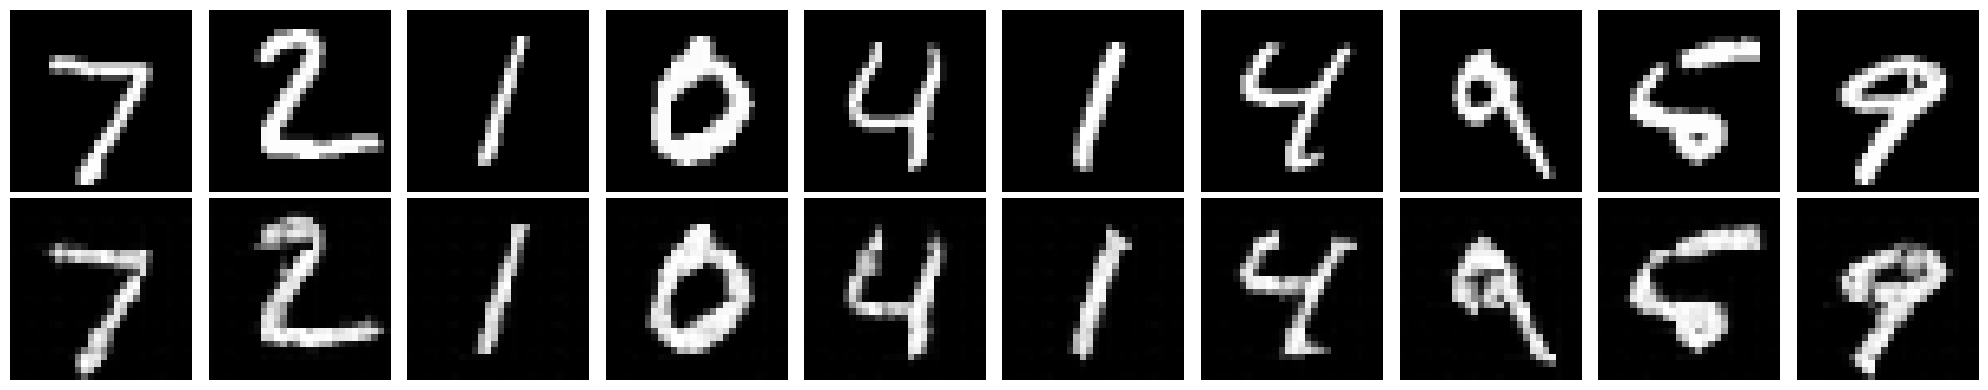

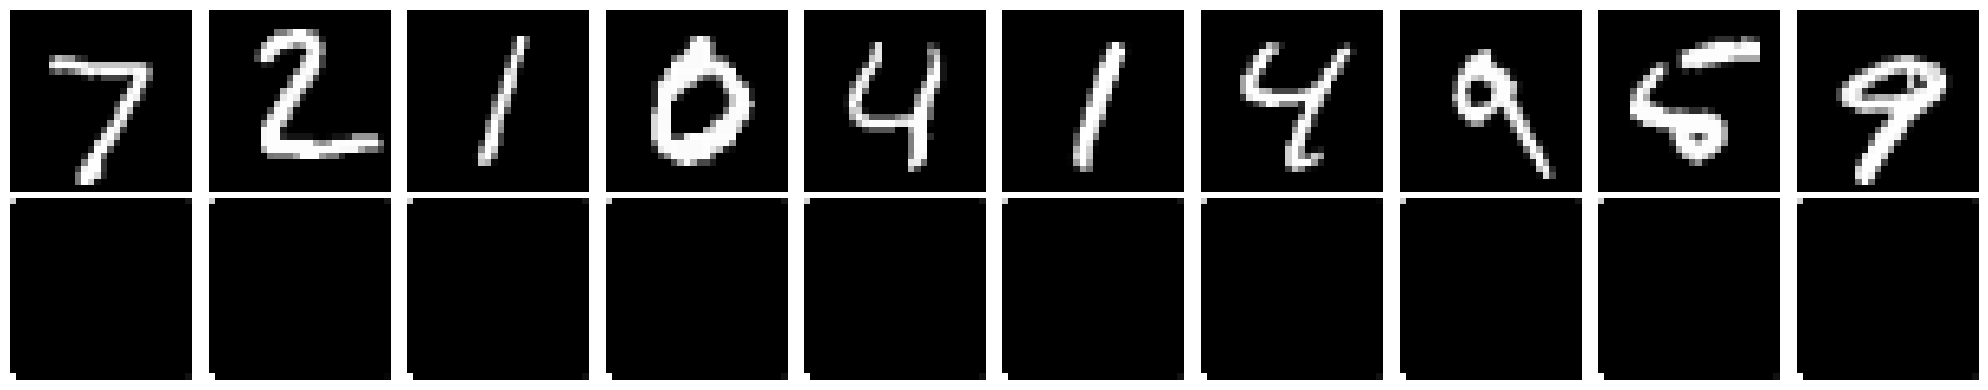

In [11]:
# Results
test(model_1, "fully")
test(model_2, "conv")
test(model_3, "conv")